In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cấu hình hiển thị đồ họa nền chuẩn
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [8]:
def load_data():
    # Đọc trực tiếp từ tệp đơn titanic_disaster.csv của bạn
    df = pd.read_csv('titanic_disaster.csv')
    return df

# Khởi chạy tải dữ liệu
df = load_data()
print("--- 10 DÒNG ĐẦU TIÊN CỦA TẬP DỮ LIỆU ---")
print(df.head(10))

--- 10 DÒNG ĐẦU TIÊN CỦA TẬP DỮ LIỆU ---
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   
5            6         0       3   
6            7         0       1   
7            8         0       3   
8            9         1       3   
9           10         1       2   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   
5                                   Moran, Mr. James    male   NaN      0   
6                      


--- THỐNG KÊ GIÁ TRỊ THIẾU TRÊN CÁC BIẾN SỐ ---
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


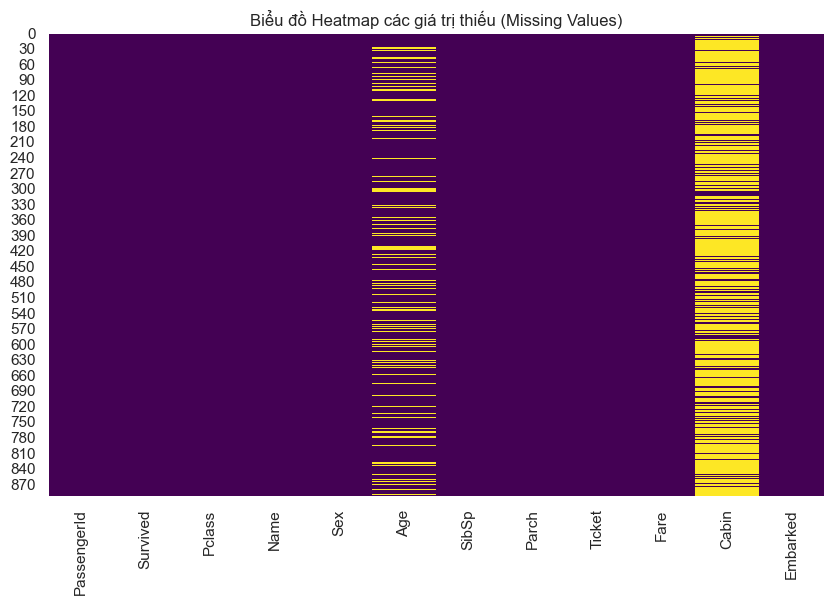

In [9]:
print("\n--- THỐNG KÊ GIÁ TRỊ THIẾU TRÊN CÁC BIẾN SỐ ---")
print(df.isnull().sum())

# Vẽ biểu đồ Heatmap nhận diện vị trí dữ liệu trống
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Biểu đồ Heatmap các giá trị thiếu (Missing Values)')
plt.show()

In [10]:
# Thực hiện tách chuỗi dựa trên dấu phẩy đầu tiên phân tách Họ và Tên
df[['secondName', 'firstName']] = df['Name'].str.split(',', n=1, expand=True)

# Làm sạch khoảng trắng dư thừa ở hai đầu chuỗi sau khi tách
df['firstName'] = df['firstName'].str.strip()
df['secondName'] = df['secondName'].str.strip()

# Xóa bỏ hoàn toàn cột Name gốc khỏi DataFrame
df.drop(columns=['Name'], inplace=True)

In [11]:
df['Sex'] = df['Sex'].map({'male': 'M', 'female': 'F'})

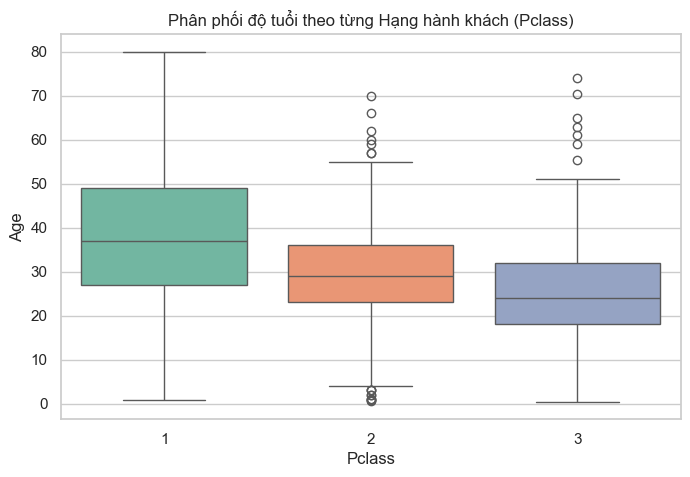

In [13]:
plt.figure(figsize=(8, 5))
# Đã cập nhật thêm hue='Pclass' và legend=False theo đúng chuẩn Seaborn v0.14+
sns.boxplot(x='Pclass', y='Age', data=df, hue='Pclass', palette='Set2', legend=False)
plt.title('Phân phối độ tuổi theo từng Hạng hành khách (Pclass)')
plt.show()


Tuổi trung bình theo từng phân lớp Pclass:
Pclass
1    38.233441
2    29.877630
3    25.140620
Name: Age, dtype: float64


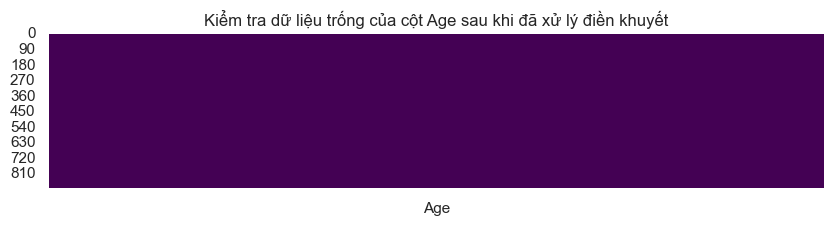

In [14]:
# Tính toán giá trị tuổi trung bình cụ thể của mỗi Pclass
age_mean_by_pclass = df.groupby('Pclass')['Age'].mean()
print("\nTuổi trung bình theo từng phân lớp Pclass:")
print(age_mean_by_pclass)

# Khớp và điền khuyết giá trị Age dựa theo mã Pclass tương ứng của hành khách đó
df['Age'] = df.apply(lambda row: age_mean_by_pclass[row['Pclass']] if np.isnan(row['Age']) else row['Age'], axis=1)

# Kiểm tra lại trạng thái trống của cột Age sau xử lý bằng Heatmap nhanh
plt.figure(figsize=(10, 2))
sns.heatmap(df[['Age']].isnull(), cbar=False, cmap='viridis')
plt.title('Kiểm tra dữ liệu trống của cột Age sau khi đã xử lý điền khuyết')
plt.show()

In [15]:
def create_age_group(age):
    if age <= 12:
        return 'Kid'
    elif age <= 18:
        return 'Teen'
    elif age <= 60:
        return 'Adult'
    else:
        return 'Older'

df['Agegroup'] = df['Age'].apply(create_age_group)

# Định nghĩa dữ liệu dạng phân loại có phân cấp thứ tự cụ thể (Ordinal)
df['Agegroup'] = pd.Categorical(df['Agegroup'], categories=['Kid', 'Teen', 'Adult', 'Older'], ordered=True)

In [16]:
# Trích xuất từ đầu tiên nằm trước dấu chấm ở cột firstName vừa tách được tại mục 3
df['namePrefix'] = df['firstName'].str.split('.').str[0]

# Giữ lại 4 danh xưng chính theo yêu cầu, các trường hợp thiểu số quy về nhóm 'Rare'
def clean_prefix(prefix):
    if prefix in ['Mr', 'Mrs', 'Miss', 'Master']:
        return prefix
    else:
        return 'Rare'

df['namePrefix'] = df['namePrefix'].apply(clean_prefix)

In [17]:
# Tính kích thước nhóm thân quen: Anh em/Vợ chồng (SibSp) + Cha mẹ/Con cái (Parch) + Bản thân hành khách (1)
df['familySize'] = df['SibSp'] + df['Parch'] + 1

# Tạo đặc trưng Alone: Nếu familySize == 1 (tức đi một mình) thì giá trị Alone = 1, ngược lại gán bằng 0
df['Alone'] = df['familySize'].apply(lambda x: 1 if x == 1 else 0)

In [18]:
# Thay thế toàn bộ trường hợp khuyết thiếu của cột Cabin bằng chuỗi danh nghĩa "Unknown"
df['Cabin'] = df['Cabin'].fillna('Unknown')

# Tách ký tự chữ cái đầu tiên đại diện cho dãy tầng/khu vực Cabin của hành khách
df['typeCabin'] = df['Cabin'].astype(str).str[0]

# Gán toàn bộ tập dữ liệu hoàn thiện sang eda_df để thực hiện phân tích trực quan hóa
eda_df = df.copy()
print("\n=== HOÀN THÀNH TOÀN BỘ BƯỚC CHUẨN BỊ VÀ BIẾN ĐỔI DỮ LIỆU ===")


=== HOÀN THÀNH TOÀN BỘ BƯỚC CHUẨN BỊ VÀ BIẾN ĐỔI DỮ LIỆU ===


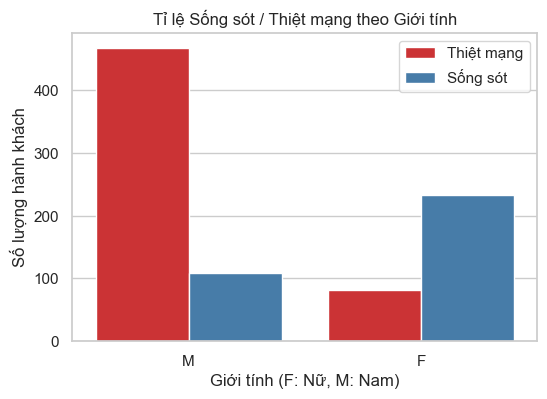

In [19]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Sex', hue='Survived', data=eda_df, palette='Set1')
plt.title('Tỉ lệ Sống sót / Thiệt mạng theo Giới tính')
plt.xlabel('Giới tính (F: Nữ, M: Nam)')
plt.ylabel('Số lượng hành khách')
plt.legend(['Thiệt mạng', 'Sống sót'])
plt.show()

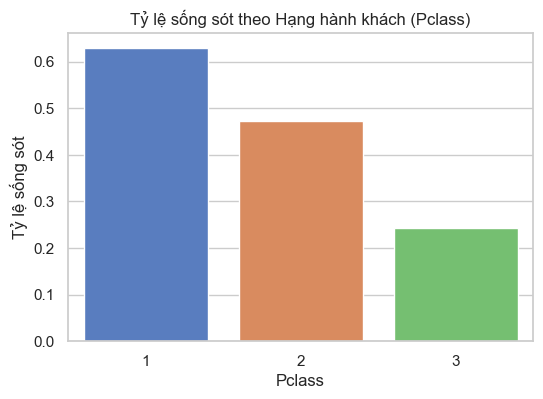

In [21]:
plt.figure(figsize=(6, 4))
sns.barplot(x='Pclass', y='Survived', data=eda_df, errorbar=None, hue='Pclass', palette='muted', legend=False)
plt.title('Tỷ lệ sống sót theo Hạng hành khách (Pclass)')
plt.ylabel('Tỷ lệ sống sót')
plt.show()

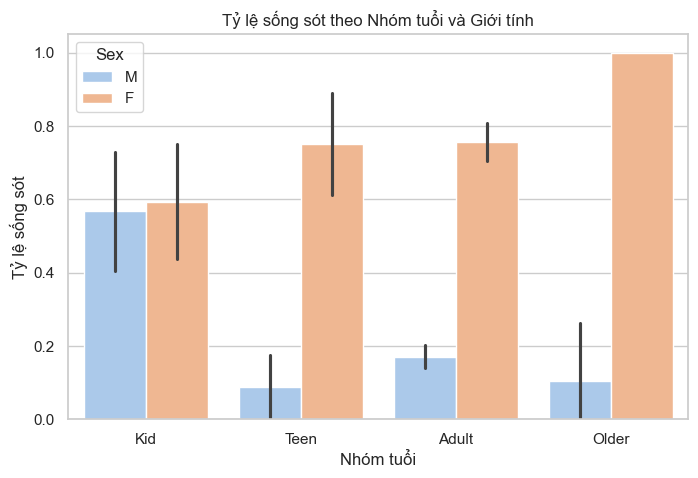

In [22]:
plt.figure(figsize=(8, 5))
# Biểu đồ này dùng hue='Sex' để phân tách giới tính nên chuẩn cú pháp bản gốc
sns.barplot(x='Agegroup', y='Survived', hue='Sex', data=eda_df, palette='pastel')
plt.title('Tỷ lệ sống sót theo Nhóm tuổi và Giới tính')
plt.ylabel('Tỷ lệ sống sót')
plt.xlabel('Nhóm tuổi')
plt.show()

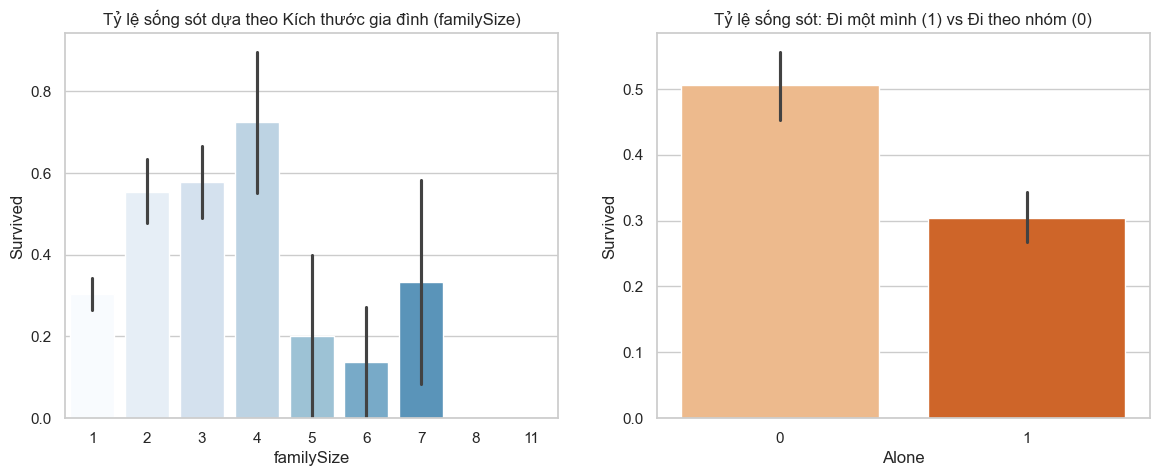

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Biểu đồ 1: Sửa lỗi cảnh báo bằng cách thêm hue='familySize' và legend=False
sns.barplot(x='familySize', y='Survived', data=eda_df, hue='familySize', palette='Blues', legend=False, ax=axes[0])
axes[0].set_title('Tỷ lệ sống sót dựa theo Kích thước gia đình (familySize)')

# Biểu đồ 2: Sửa lỗi cảnh báo bằng cách thêm hue='Alone' và legend=False
sns.barplot(x='Alone', y='Survived', data=eda_df, hue='Alone', palette='Oranges', legend=False, ax=axes[1])
axes[1].set_title('Tỷ lệ sống sót: Đi một mình (1) vs Đi theo nhóm (0)')

plt.show()

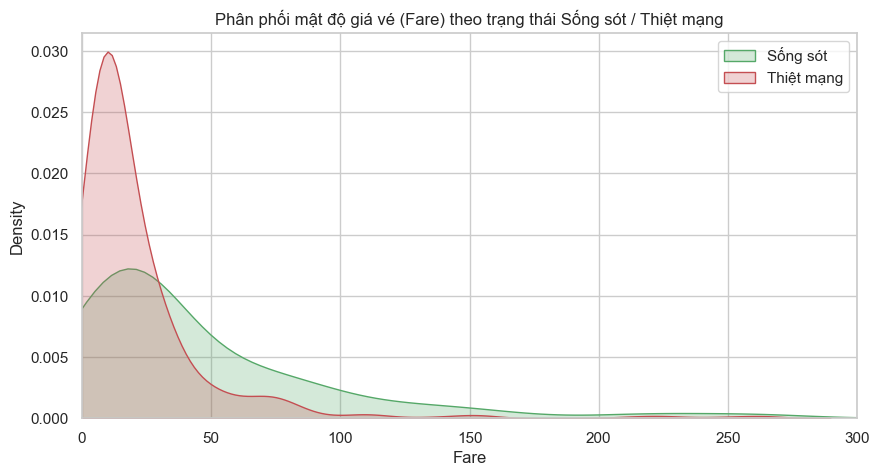

In [24]:
plt.figure(figsize=(10, 5))
# Sử dụng tham số fill=True thay thế cho shade=True (shade đã lỗi thời ở bản mới)
sns.kdeplot(data=eda_df[eda_df['Survived'] == 1], x='Fare', label='Sống sót', fill=True, color='g')
sns.kdeplot(data=eda_df[eda_df['Survived'] == 0], x='Fare', label='Thiệt mạng', fill=True, color='r')
plt.title('Phân phối mật độ giá vé (Fare) theo trạng thái Sống sót / Thiệt mạng')
plt.xlim(0, 300) # Thu hẹp khoảng giá vé phổ biến để biểu đồ trực quan, sắc nét hơn
plt.legend()
plt.show()

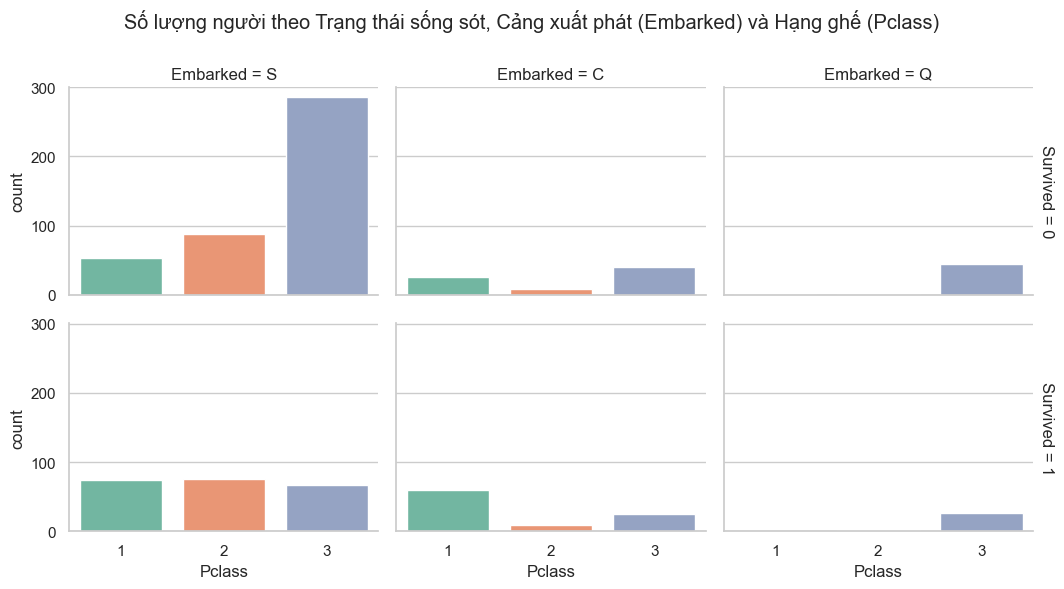

In [26]:

g = sns.catplot(
    data=eda_df, 
    x="Pclass", 
    col="Embarked", 
    row="Survived", 
    kind="count", 
    hue="Pclass", 
    palette="Set2", 
    legend=False,
    height=3, 
    aspect=1.2,
    margin_titles=True
)

# Tinh chỉnh khoảng cách và thêm tiêu đề tổng thể cho biểu đồ
g.fig.subplots_adjust(top=0.85)
g.fig.suptitle('Số lượng người theo Trạng thái sống sót, Cảng xuất phát (Embarked) và Hạng ghế (Pclass)')

plt.show()